# Result Analysis

In [1]:
import chess
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

sns.set_style("darkgrid")

ELOS = list(range(500, 2500, 100))

In [2]:
df = pd.read_parquet("../data/recommendation_dataset.parquet")
df.tail()

,fen,next_move,played_by_elo,win_pov,games_count,engine_move,delta,fragility_score,variance,group_count_300,...,is_best_2500,is_engine_best_2500,score_2600,recommended_move_2600,is_best_2600,is_engine_best_2600,score_2700,recommended_move_2700,is_best_2700,is_engine_best_2700
1001886,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,d7d5,1834,False,145903,g8f6,0.284366,-0.788823,-0.174046,176.0,...,True,<NA>,0.676796,d7d5,True,<NA>,0.923322,d7d5,True,<NA>
1001887,rnbqkbnr/ppp1pppp/8/3p4/3P4/8/PPP1PPPP/RNBQKBN...,c1f4,1835,True,145903,c2c4,-0.612085,-0.807181,-0.156649,173.0,...,True,<NA>,0.603560,c1f4,True,<NA>,0.829429,c1f4,True,<NA>
1001888,rnbqkbnr/ppp1pppp/8/3p4/3P1B2/8/PPP1PPPP/RN1QK...,c7c6,1834,False,10250,e7e6,-0.845942,-0.715394,-0.169172,6.0,...,False,False,0.522054,c8f5,False,False,0.718112,c8f5,False,False
1001889,rnbqkbnr/pp2pppp/2p5/3p4/3P1B2/8/PPP1PPPP/RN1Q...,g1f3,1835,True,2449,e2e3,-0.495157,-0.109598,-0.132579,NaN,...,True,False,0.096277,c2c3,True,False,0.130198,c2c3,<NA>,<NA>
1001890,rnbqkbnr/pp2pppp/2p5/3p4/3P1B2/5N2/PPP1PPPP/RN...,c8g4,1834,False,156,c8f5,-1.001847,-0.036168,-0.159541,NaN,...,<NA>,<NA>,0.010708,c8f5,<NA>,<NA>,0.014539,c8f5,<NA>,<NA>


## Prediction accuracy

In [3]:
results = []
grouped = df.groupby("fen").first().reset_index()


def weighted_mean(values, weights):
    mask = values.notna() & weights.notna()
    if mask.sum() == 0:
        return float("nan")
    return (values[mask] * weights[mask]).sum() / weights[mask].sum()


for elo in ELOS:
    # Spaltennamen
    is_best_col      = f"is_best_{elo}"
    is_top2_col      = f"is_top2_{elo}"
    is_top3_col      = f"is_top3_{elo}"
    is_engine1_col   = f"is_engine_best_{elo}"
    is_engine2_col   = f"is_engine_top2_{elo}"
    is_engine3_col   = f"is_engine_top3_{elo}"
    group_count_col  = f"group_count_{elo}"

    # Gewichtet Mittelwerte
    wa_best    = weighted_mean(grouped[is_best_col],    grouped[group_count_col])
    wa_top2    = weighted_mean(grouped[is_top2_col],    grouped[group_count_col])
    wa_top3    = weighted_mean(grouped[is_top3_col],    grouped[group_count_col])
    wa_eng1    = weighted_mean(grouped[is_engine1_col], grouped[group_count_col])
    wa_eng2    = weighted_mean(grouped[is_engine2_col], grouped[group_count_col])
    wa_eng3    = weighted_mean(grouped[is_engine3_col], grouped[group_count_col])

    results.append({
        "elo": elo,
        "avg_is_best": wa_best,
        "avg_is_top2": wa_top2,
        "avg_is_top3": wa_top3,
        "avg_is_engine_best": wa_eng1,
        "avg_is_engine_top2": wa_eng2,
        "avg_is_engine_top3": wa_eng3
    })

results = pd.DataFrame(results).set_index("elo")
results

KeyError: 'is_top2_500'

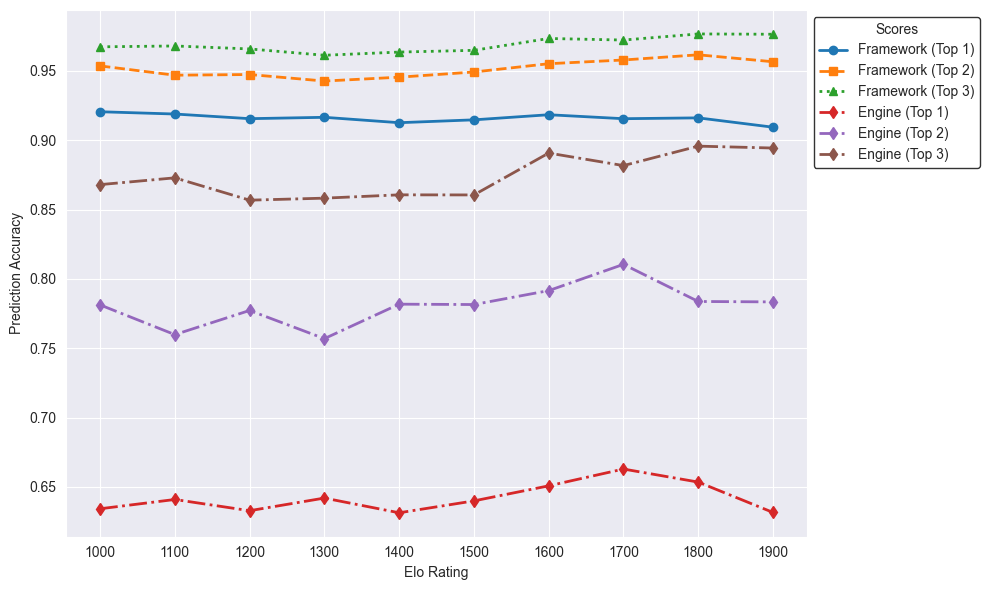

In [63]:
plt.figure(figsize=(10, 6))

plt.plot(results.index, results["avg_is_best"].values,   marker="o", linewidth=2, label="Framework (Top 1)")
plt.plot(results.index, results["avg_is_top2"].values,   marker="s", linestyle="--", linewidth=2, label="Framework (Top 2)")
plt.plot(results.index, results["avg_is_top3"].values,   marker="^", linestyle=":", linewidth=2, label="Framework (Top 3)")

# Engine Top-K
plt.plot(results.index, results["avg_is_engine_best"].values, marker="d", linestyle="-.", linewidth=2, label="Engine (Top 1)")
plt.plot(results.index, results["avg_is_engine_top2"].values, marker="d", linestyle="-.", linewidth=2, label="Engine (Top 2)")
plt.plot(results.index, results["avg_is_engine_top3"].values, marker="d", linestyle="-.", linewidth=2, label="Engine (Top 3)")

plt.xlabel("Elo Rating")
plt.ylabel("Prediction Accuracy")
plt.xticks(results.index)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), title="Scores", facecolor="white", edgecolor="black")
plt.tight_layout()
plt.savefig("../images/prediction_accuracy_topk.pdf", bbox_inches="tight")
plt.show()


## Move selection decision

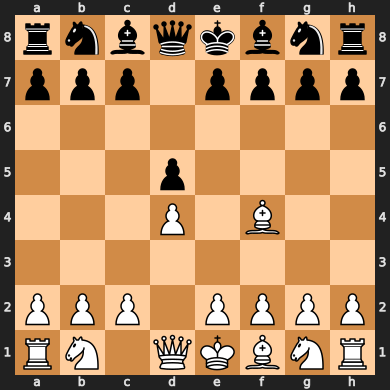

In [64]:
mv_fen = df["fen"].value_counts().idxmax()
chess.Board(mv_fen)

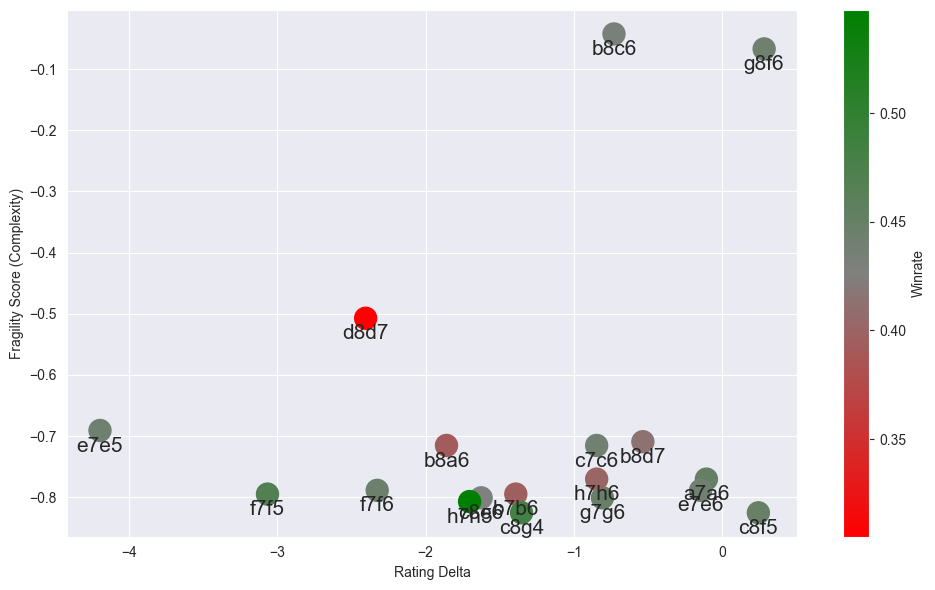

In [65]:
mv_pos = df[df["fen"] == mv_fen]
cmap = mpl.colors.LinearSegmentedColormap.from_list("RG", ["red", "gray", "green"])

plt.figure(figsize=(10, 6))
sc = plt.scatter(
    mv_pos['delta'],
    mv_pos['fragility_score'],
    c=mv_pos['global_winrate'],
    cmap=cmap,
    s=250
)

for _, row in mv_pos.iterrows():
    plt.text(
        row['delta'],
        row['fragility_score'] - 0.01,
        row['next_move'],
        fontsize=15,
        ha='center',
        va='top'
    )

plt.xlabel("Rating Delta")
plt.ylabel("Fragility Score (Complexity)")
plt.colorbar(sc, label='Winrate')
plt.tight_layout()
plt.savefig("../images/selection_decision.svg")
plt.show()

## Sample position

In [66]:
random_fen = df["fen"].sample(1).iloc[0]
# random_fen = "rn1qkbnr/pp3ppp/4p3/3p1b2/3P1B2/2N2N2/PPP2PPP/R2QKB1R b KQkq - 1 6"
filtered = df[df["fen"] == random_fen]
filtered.drop("fen", axis=1).set_index('next_move').T

next_move,a7a6,c8f5,c8g4,e7e6,f6e4
games_count,147,684,658,786,113
global_avg_elo,1439.37415,1337.859649,1421.253799,1388.0,1221.654867
global_winrate,0.428571,0.431287,0.452888,0.441476,0.460177
engine_move,c8g4,c8g4,c8g4,c8g4,c8g4
delta,-0.495157,-0.729014,0.713103,0.167437,0.24539
...,...,...,...,...,...
is_top2_1900,True,True,True,True,<NA>
is_top3_1900,True,True,True,True,<NA>
is_engine_best_1900,False,False,False,False,<NA>
is_engine_top2_1900,False,False,False,False,<NA>


In [67]:
print(random_fen)

r1bqkb1r/ppp1pppp/2n2n2/3p4/3P1B2/4PN2/PPP2PPP/RN1QKB1R b KQkq - 0 4


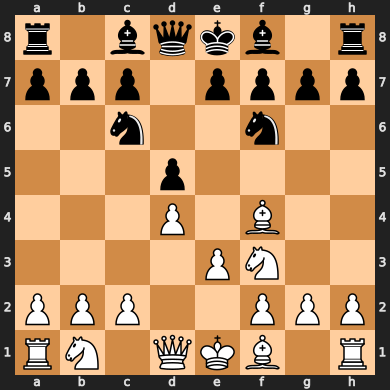

In [68]:
chess.Board(random_fen)

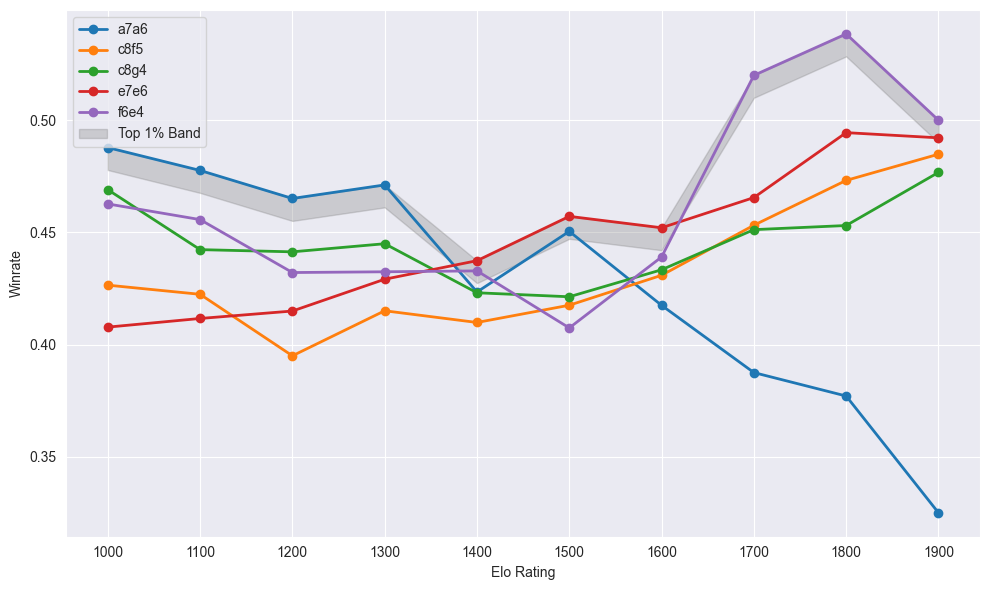

In [69]:
df_sample = filtered.set_index('next_move')
columns_starting_with_winrate = df_sample.columns[df_sample.columns.str.startswith("winrate_")]
filtered_columns_df = df_sample[columns_starting_with_winrate]
filtered_columns_df.columns = filtered_columns_df.columns.str.replace(r"^winrate_", "", regex=True)
winrate_df = filtered_columns_df.T
winrate_df.index = winrate_df.index.astype(int)
top_line = winrate_df.max(axis=1).astype(float).values
bottom_line = (winrate_df.max(axis=1) - 0.01).astype(float).values
elo_index = winrate_df.index.values

plt.figure(figsize=(10, 6))

for col in winrate_df.columns:
    plt.plot(elo_index, winrate_df[col].values, marker='o', linewidth=2, label=col)

plt.fill_between(elo_index, bottom_line, top_line, color='gray', alpha=0.3, label="Top 1% Band")

plt.xlabel("Elo Rating")
plt.ylabel("Winrate")
plt.xticks(winrate_df.index)
plt.legend()
plt.tight_layout()
plt.savefig("../images/winrate_example.svg")
plt.show()

## Evaluate with Logistic Regression and XGBoost

In [70]:
df["f_cross_d"] = df["fragility_score"] * df["delta"]
df["f_cross_v"] = df["fragility_score"] * df["variance"]
df["d_cross_v"] = df["delta"] * df["variance"]

target_columns = [col for col in df.columns if col.startswith("is_best_") or col.startswith("is_engine_best_")]

for y_feature in target_columns:
    print(f"{y_feature}:")
    df_reg = df[pd.notna(df[y_feature])]

    selected_features = ["fragility_score", "delta", "variance", "f_cross_d", "f_cross_v", "d_cross_v"]
    X = df_reg[selected_features]
    y = df_reg[y_feature].astype(bool)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=1, stratify=y
    )

    log_model = LogisticRegression()
    log_model.fit(X_train, y_train)
    y_pred_log = log_model.predict(X_test)
    acc_log = accuracy_score(y_test, y_pred_log)
    print(f"Logistic Regression Accuracy: {acc_log * 100:.1f} %")

    xgb_model = XGBClassifier()
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    acc_xgb = accuracy_score(y_test, y_pred_xgb)
    print(f"XGBoost Accuracy: {acc_xgb * 100:.1f} %")
    print()

is_best_1000:
Logistic Regression Accuracy: 63.2 %
XGBoost Accuracy: 61.1 %

is_engine_best_1000:
Logistic Regression Accuracy: 59.7 %
XGBoost Accuracy: 58.6 %

is_best_1100:
Logistic Regression Accuracy: 57.3 %
XGBoost Accuracy: 53.0 %

is_engine_best_1100:
Logistic Regression Accuracy: 63.7 %
XGBoost Accuracy: 66.3 %

is_best_1200:
Logistic Regression Accuracy: 61.9 %
XGBoost Accuracy: 57.1 %

is_engine_best_1200:
Logistic Regression Accuracy: 63.4 %
XGBoost Accuracy: 57.9 %

is_best_1300:
Logistic Regression Accuracy: 63.4 %
XGBoost Accuracy: 60.1 %

is_engine_best_1300:
Logistic Regression Accuracy: 61.0 %
XGBoost Accuracy: 60.0 %

is_best_1400:
Logistic Regression Accuracy: 61.8 %
XGBoost Accuracy: 61.1 %

is_engine_best_1400:
Logistic Regression Accuracy: 61.2 %
XGBoost Accuracy: 61.2 %

is_best_1500:
Logistic Regression Accuracy: 62.0 %
XGBoost Accuracy: 58.0 %

is_engine_best_1500:
Logistic Regression Accuracy: 65.7 %
XGBoost Accuracy: 61.4 %

is_best_1600:
Logistic Regression 